In [1]:
import numpy as np
import matplotlib.pyplot as pl
from five_vec import five_vec

## PBH signal

In [3]:
def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

def f_calc(f0, beta, t):
    return f0*(1-8/3*beta*t)**(-3/8)

In [14]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

f0 = 20
Mc = 1e-1* 2e30
f_max = 200
beta = const*f0**(8/3)*Mc**(5/3)
T_obs = min(t_max_calc(f0, beta, f_max), 1e4)

f_signal = 5*f_max
nt = round(f_signal*T_obs)
t = np.arange(nt)/f_signal

phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
temp_signal = np.real(np.exp(1j*phi))

mono = np.exp(1j*2*pi*f0*t)

In [44]:
beta = const*f0**(8/3)*(1e-2*2e30)**(5/3)
t_max_calc(f0, beta, f_max)/86164

5.44922106989845

In [16]:
f = f_calc(f0, beta, t)
d = 8e3*3.086e+16 # 8kpc
h0 = 4/d*(G*Mc/c**2)**(5/3)*(pi*f/c)**(2/3)

In [18]:
params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = 0.5, lng = 0.5, az = 0.5)
sidereal = five_vec(**params)
sidereal.compute_H()
sidereal.compute_A(t)
sidereal.compute_5vec()
amp_modulation = sidereal.amp_modulation

## Signal with amplitude evolution + modulation but no frequency evolution

In [27]:
signal = h0*mono*amp_modulation
fft_freqs = np.fft.fftshift(np.fft.fftfreq(len(signal), np.diff(t)[0]))
fft_amps = np.fft.fftshift(np.fft.fft(signal))/len(signal)

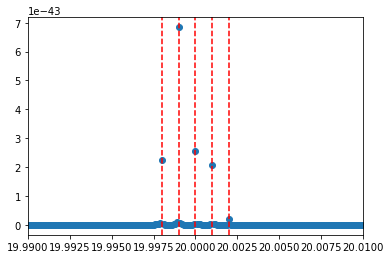

In [28]:
side_day= 1000
pl.plot(fft_freqs, abs(fft_amps)**2, 'o')
pl.xlim(19.99, 20.01)
pl.axvline(f0-2/side_day, c='r', ls='--')
pl.axvline(f0-1/side_day, c='r', ls='--')
pl.axvline(f0, c='r', ls='--')
pl.axvline(f0+1/side_day, c='r', ls='--')
pl.axvline(f0+2/side_day, c='r', ls='--')

In [29]:
X = np.empty((5), dtype=complex)

X[0] = fft_amps[abs(fft_freqs-(f0-2/side_day)).argmin()]
X[1] = fft_amps[abs(fft_freqs-(f0-1/side_day)).argmin()]
X[2] = fft_amps[abs(fft_freqs-f0).argmin()]
X[3] = fft_amps[abs(fft_freqs-(f0+1/side_day)).argmin()]
X[4] = fft_amps[abs(fft_freqs-(f0+2/side_day)).argmin()]

In [32]:
estimator = abs(np.dot(X, np.conj(sidereal.A))/np.sum(np.abs(sidereal.A)**2))

Text(0, 0.5, 'h0')

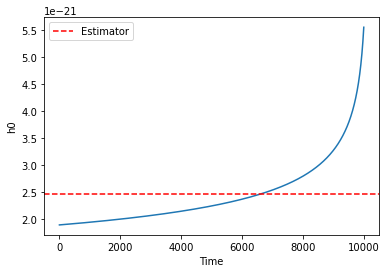

In [47]:
pl.plot(t[::100], h0[::100])
pl.axhline(estimator, c='r', ls='--', label = 'Estimator')
pl.legend()
pl.xlabel("Time")
pl.ylabel("h0")

In [41]:
print(np.average(h0))
print(estimator)

2.4631019139986573e-21
2.4666386149599913e-21
